In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import glob

from src.parsers import HMParser, CotevParser

from src.utils import load_multiple_upacs_pv, iterate_resources

2025-01-14 19:46:17,188	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!


In [2]:
# Data parsing

# EC data for non-renewable generators and batteries
data_ec = HMParser(file_path='/Users/ecgomes/DataspellProjects/pyecom/data/EC_V4.xlsx', ec_id=1)
data_ec.parse()

# EV data from the EV4EU simulator
data_ev = CotevParser(population_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/population_731.csv',
                      driving_history_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/ev_driving_history_731.csv',
                      assigned_segments_path='/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/assigned_segments_731.csv',
                      parse_date_start='2019',
                      parse_date_end='2020')
data_ev.parse()

# UPAC Data load
data_upacs = load_multiple_upacs_pv('/Users/ecgomes/Documents/PhD/UPAC data/upac*_pv.csv', resample='H')

In [3]:
# Create resources for the training environment

dataset_resources = iterate_resources(u=data_upacs, c=data_ec, e=data_ev, mode='monthly')

In [4]:
# Load the data

test_data = pd.DataFrame({})
for file in glob.glob('../priority_paper_v0/*.csv'):
    data = pd.read_csv(file, index_col=0)
    name = file.split('/')[-1].split('.')[0]
    
    # Create index for data
    data.index = pd.date_range(start=name, periods=data.shape[0], freq='H')
    
    # Add data to the DataFrame
    test_data = pd.concat([test_data, data], axis=0)
    
# Sort the data
test_data = test_data.sort_index()

In [5]:
test_data.iloc[:1440]

,ren_generator_08,ren_generator_06,ren_generator_02,ren_generator_09,ren_generator_13,storage_01,storage_01_charge,storage_01_discharge,storage_02,storage_02_charge,...,ev_04,ev_04_charge,ev_04_discharge,ev_05,ev_05_charge,ev_05_discharge,imports,exports,energy_history,order_history
2019-01-01 00:00:00,0.0,0.001306,0.0,0.000010,0.0,0.800,0.0,0.0,0.838400,4.000000,...,0.838118,2.8800,0.0,0.855385,4.3200,0.0,25.701656,0.0,-25.701656,"['ren_generator_09', 'ren_generator_08', 'ren_..."
2019-01-01 01:00:00,0.0,0.001228,0.0,0.000024,0.0,0.800,0.0,0.0,0.876800,4.000000,...,0.876235,2.8800,0.0,0.895538,3.1320,0.0,25.452336,0.0,-25.452336,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-01-01 02:00:00,0.0,0.001312,0.0,0.000023,0.0,0.800,0.0,0.0,0.899072,2.320000,...,0.897624,1.6160,0.0,0.899554,0.3132,0.0,11.269682,0.0,-11.269682,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-01-01 03:00:00,0.0,0.001370,0.0,0.000005,0.0,0.838,2.0,0.0,0.899963,0.092800,...,0.899762,0.1616,0.0,0.899956,0.0313,0.0,6.464711,0.0,-6.464711,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-01-01 04:00:00,0.0,0.001287,0.0,0.000008,0.0,0.876,2.0,0.0,0.899999,0.003712,...,0.899976,0.0162,0.0,0.899996,0.0031,0.0,5.487456,0.0,-5.487456,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-03-01 19:00:00,0.0,0.000686,0.0,0.000000,0.0,0.900,0.0,0.0,0.900000,0.000000,...,0.836957,2.1600,0.0,0.896319,2.5839,0.0,12.819909,0.0,-12.819909,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-03-01 20:00:00,0.0,0.000672,0.0,0.000000,0.0,0.900,0.0,0.0,0.900000,0.000000,...,0.865546,2.1600,0.0,0.899632,0.2584,0.0,10.168146,0.0,-10.168146,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-03-01 21:00:00,0.0,0.000640,0.0,0.000000,0.0,0.900,0.0,0.0,0.900000,0.000000,...,0.894134,2.1600,0.0,0.899963,0.0258,0.0,9.477791,0.0,-9.477791,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."
2019-03-01 22:00:00,0.0,0.000645,0.0,0.000000,0.0,0.900,0.0,0.0,0.900000,0.000000,...,0.899413,0.3989,0.0,0.899996,0.0026,0.0,7.128723,0.0,-7.128723,"['storage_03', 'ev_05', 'ev_04', 'ev_03', 'ev_..."


In [6]:
# Check day '2020-01-01'
# We want to build a consumption and a production dataframe
# Consumption will have the load, the storage charge, the EV charge and the exports
# Production will have the renewable generators, the non-renewable generators, the storage discharge and the EV discharge
# Load will come from the UPAC data

DATE = '2020'

# Create the consumption dataframe
consumption = pd.DataFrame(index=test_data.index, columns=['load', 'storage_charge',
                                                                     'ev_charge', 'exports'])
consumption['load'] = sum(data_upacs[key].load.values for key in data_upacs.keys())
consumption['storage_charge'] = test_data[['storage_01_charge',
                                                     'storage_02_charge',
                                                     'storage_03_charge']].sum(axis=1)
consumption['ev_charge'] = test_data.loc[DATE][['ev_01_charge',
                                                          'ev_02_charge',
                                                          'ev_03_charge',
                                                          'ev_04_charge',
                                                          'ev_05_charge']].sum(axis=1)
consumption['exports'] = test_data['exports']

# Create the production dataframe
production = pd.DataFrame(index=test_data.index, columns=['ren_gen',
                                                                    #'non_ren_gen', 
                                                                    'storage_discharge',
                                                                    'ev_discharge'])
production['ren_gen'] = test_data[['ren_generator_02',
                                             'ren_generator_06',
                                             'ren_generator_08',
                                             'ren_generator_09',
                                             'ren_generator_13']].sum(axis=1)
#seq_production['non_ren_gen'] = sequential_data[DATE][['generator_14', 'generator_15']].sum(axis=1)
production['storage_discharge'] = test_data[['storage_01_discharge',
                                                       'storage_02_discharge',
                                                       'storage_03_discharge']].sum(axis=1)
production['ev_discharge'] = test_data.loc[DATE][['ev_01_discharge',
                                                            'ev_02_discharge',
                                                            'ev_03_discharge',
                                                            'ev_04_discharge',
                                                            'ev_05_discharge']].sum(axis=1)
production['imports'] = test_data['imports']

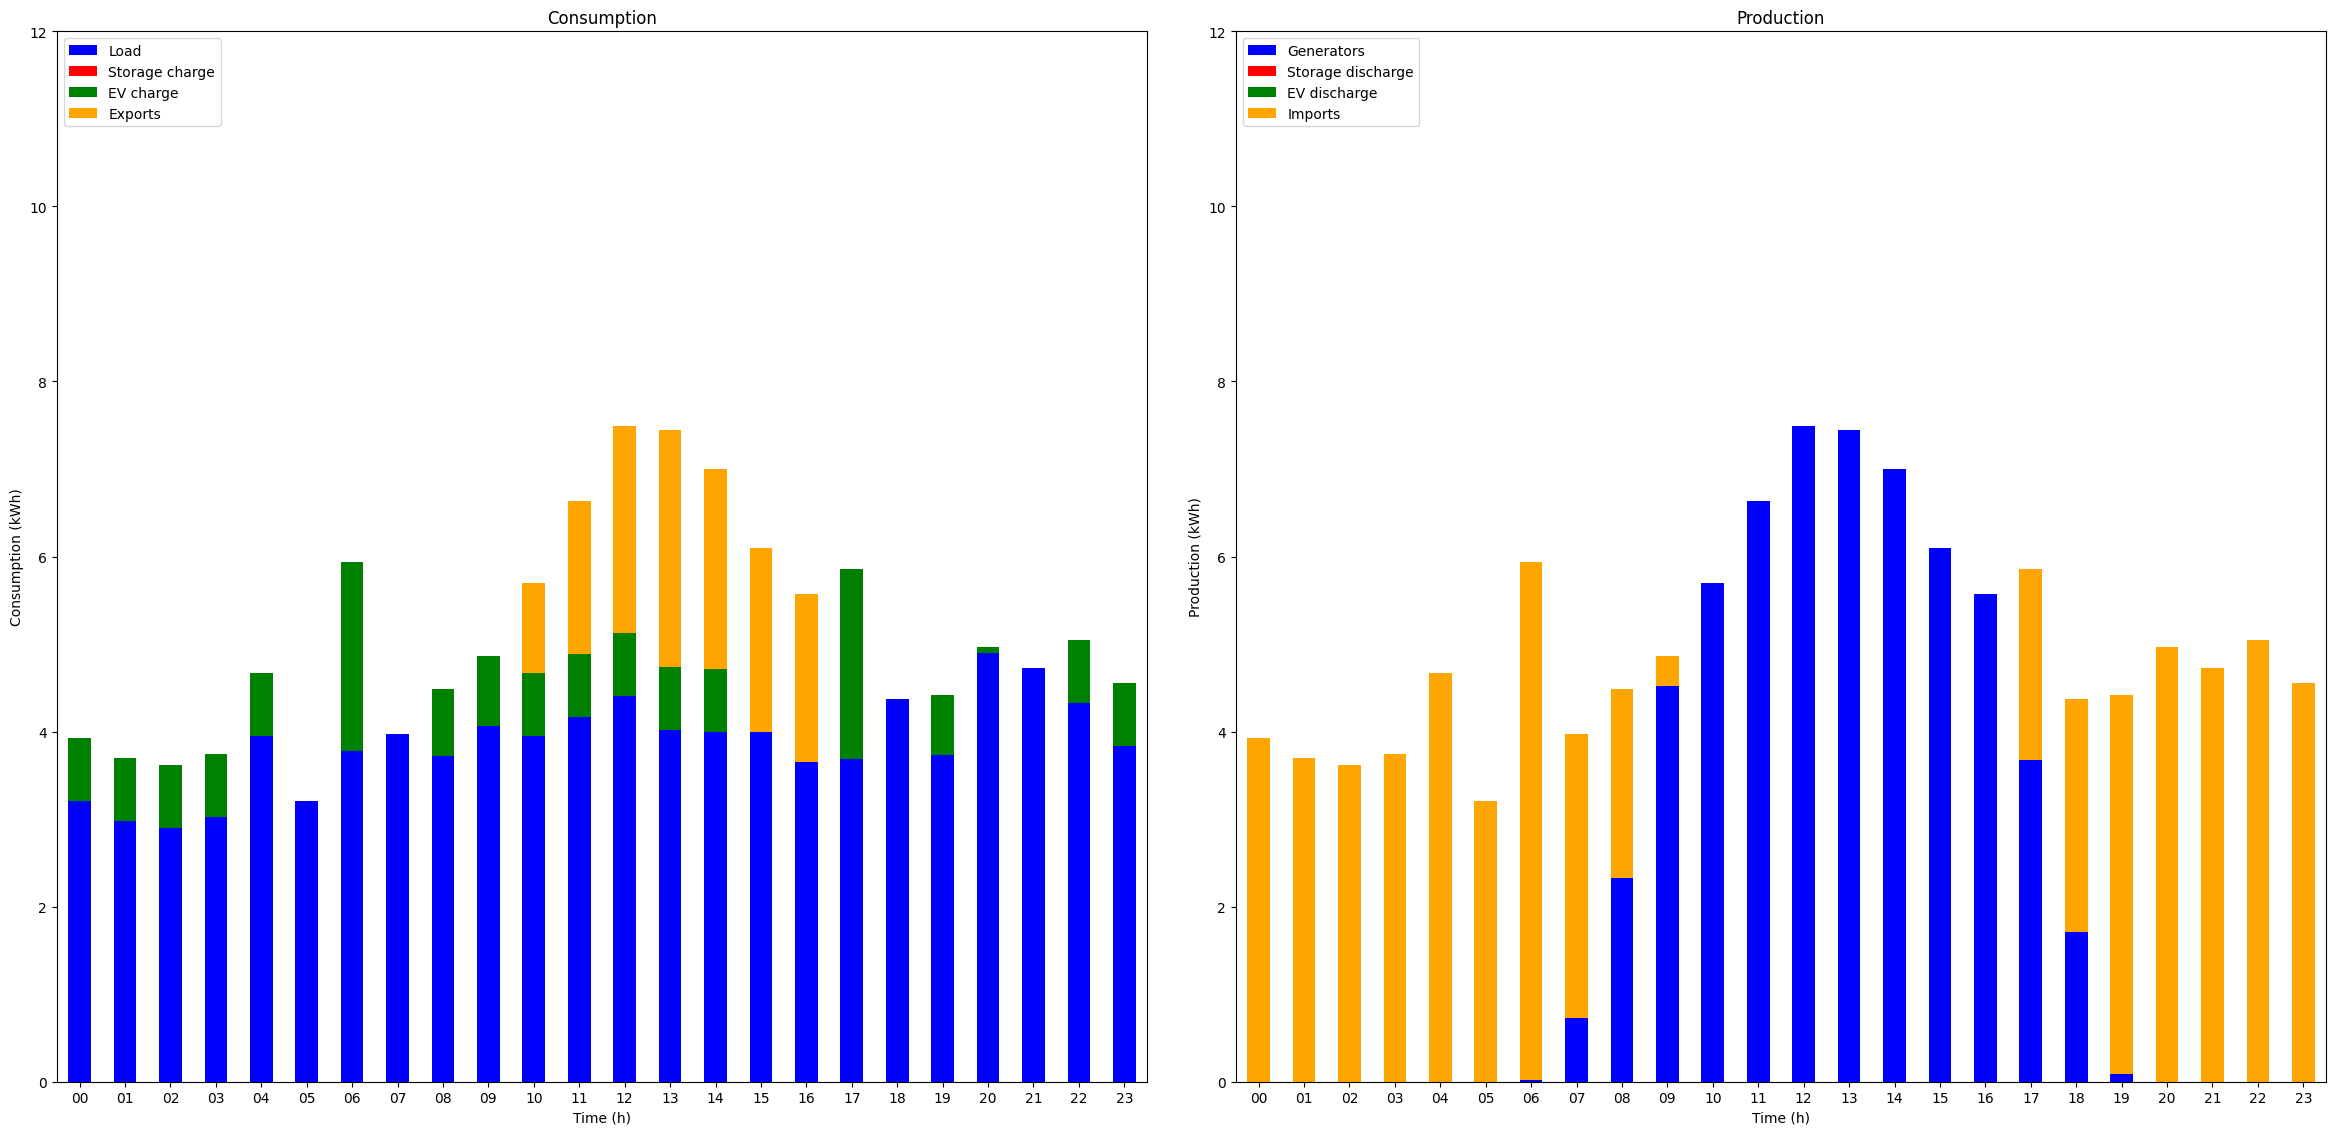

In [7]:
# Plot the stacked bar chart

DAY = '2020-08-15'

# Set the subfigures
fig, ax = plt.subplots(1, 2, figsize=(24, 12))

# Consumption data
consumption.loc[DAY].plot(kind='bar', stacked=True, ax=ax[0], color=['blue', 'red', 'green', 'orange'])

# Set the X axis to just have the hours
ax[0].set_xticklabels(consumption.loc[DAY].index.strftime('%H:%M'))

# Plot the aggregator import costs on top, with its own scale
# Create a new axis
#ax2 = ax[0, 0].twinx()
#ax2.plot(seq_consumption.loc[DAY].index, dataset_resources[DAY][-1].import_cost, color='yellow', linestyle='--')

#ax3 = ax[1, 0].twinx()
#ax3.plot(reg_consumption.loc[DAY].index, dataset_resources[DAY][-1].import_cost, color='yellow', linestyle='--')


# Set the scale to go up to 40
ax[0].set_ylim(0, 12)

# Rotate the labels to be horizontal
#ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# Set the X axis to just have the hours
ax[0].set_xticklabels(consumption.loc[DAY].index.strftime('%H'))

# Rotate the labels
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

# Add axis labels
ax[0].set_xlabel('Time (h)')

# Add axis labels
ax[0].set_ylabel('Consumption (kWh)')

# Add title
ax[0].set_title('Consumption')

# Production data
production.loc[DAY].plot(kind='bar', stacked=True, ax=ax[1], color=['blue', 'red', 'green', 'orange', 'purple'])

# Set the scale to go up to 40
ax[1].set_ylim(0, 12)

# Add axis labels
ax[1].set_xlabel('Time (h)')

# Set the X axis to just have the hours
ax[1].set_xticklabels(production.loc[DAY].index.strftime('%H'))

# Rotate the labels to be horizontal
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

# Add axis labels
ax[1].set_ylabel('Production (kWh)')

# Add title
ax[1].set_title('Production')

# Fix the labels for the legend
ax[0].legend(['Load', 'Storage charge', 'EV charge', 'Exports'], loc='upper left')

ax[1].legend(['Generators', 'Storage discharge', 'EV discharge', 'Imports'], loc='upper left')

# Scale the font
plt.rcParams.update({'font.size': 28})

plt.tight_layout()

#plt.savefig('daily_comparison_paper.png', dpi=300)

plt.show()

In [8]:
import copy

def calculate_costs(model_results, model_data):

    datapoint_dict = {}
    overall_dict = pd.DataFrame({}, index=['Costs', 'Profits'])

    for key in model_data.keys():

        current_data = model_results.loc[key].copy(deep=True)
        current_data = current_data[['ren_generator_08',
                                     'ren_generator_06',
                                     'ren_generator_02',
                                     'ren_generator_09',
                                     'ren_generator_13',
                                     'storage_01_discharge',
                                     'storage_02_discharge',
                                     'storage_03_discharge',
                                     'ev_01_discharge',
                                     'ev_02_discharge',
                                     'ev_03_discharge',
                                     'ev_04_discharge',
                                     'ev_05_discharge',
                                     'imports',
                                     'exports']]

        current_data['ren_generator_08'] *= model_data[key][0].cost
        current_data['ren_generator_06'] *= model_data[key][1].cost
        current_data['ren_generator_02'] *= model_data[key][2].cost
        current_data['ren_generator_09'] *= model_data[key][3].cost
        current_data['ren_generator_13'] *= model_data[key][4].cost

        current_data['storage_01_discharge'] *= model_data[key][10].cost_discharge
        current_data['storage_02_discharge'] *= model_data[key][11].cost_discharge
        current_data['storage_03_discharge'] *= model_data[key][12].cost_discharge

        current_data['ev_01_discharge'] *= model_data[key][13].cost_discharge
        current_data['ev_02_discharge'] *= model_data[key][14].cost_discharge
        current_data['ev_03_discharge'] *= model_data[key][15].cost_discharge
        current_data['ev_04_discharge'] *= model_data[key][16].cost_discharge
        current_data['ev_05_discharge'] *= model_data[key][17].cost_discharge

        current_data['imports'] *= model_data[key][-1].import_cost
        current_data['exports'] *= model_data[key][-1].export_cost

        current_data = current_data.round(4)

        datapoint_dict[key] = current_data

        overall_dict[key] = [current_data.sum().iloc[:-1].sum(), current_data.sum().iloc[-1]]

    overall_dict = overall_dict.T

    return overall_dict, datapoint_dict

costs, monthly_costs = calculate_costs(test_data, dataset_resources)

# Sort the index and assign it as a datetime index
costs = costs.sort_index()
costs.index = pd.to_datetime(costs.index)

df_final_costs = pd.DataFrame()
# Sort the index and assign it as a datetime index
for key in monthly_costs.keys():
    monthly_costs[key] = monthly_costs[key].sort_index()
    monthly_costs[key].index = pd.date_range(start='{}-01-01'.format(key), 
                                             periods=len(monthly_costs[key]), freq='H')
    # Only the date, exclude the hours
    #seq_monthly_costs[key].index = pd.to_datetime(seq_monthly_costs[key].index.date)

    # Append the data to the dataframe
    df_final_costs = pd.concat([df_final_costs, monthly_costs[key]])
df_final_costs = df_final_costs.sort_index()

In [9]:
# Load the sequential baseline and the regular baseline

seq_baseline = pd.read_csv('../priority_paper/sequential_costs.csv', index_col=0)

# Load the regular baseline
reg_baseline = pd.read_csv('../priority_paper/regular_costs.csv', index_col=0)

In [10]:
# Group by month

df_costs_grouped = pd.DataFrame({})
df_costs_grouped['costs']  = df_final_costs[list(df_final_costs.columns)[:-1]].sum(axis=1)
df_costs_grouped['seq_baseline'] = seq_baseline[list(seq_baseline.columns)[:-1]].sum(axis=1).values
df_costs_grouped['reg_baseline'] = reg_baseline[list(reg_baseline.columns)[:-1]].sum(axis=1).values
df_costs_grouped = df_costs_grouped.groupby([df_costs_grouped.index.year,
                                             df_costs_grouped.index.month]).sum()

df_export_grouped = pd.DataFrame({})
df_export_grouped['costs'] = df_final_costs['exports']
df_export_grouped['seq_baseline'] = seq_baseline['exports'].values
df_export_grouped['reg_baseline'] = reg_baseline['exports'].values
df_export_grouped = df_export_grouped.groupby([df_export_grouped.index.year,
                                               df_export_grouped.index.month]).sum()

In [13]:
df_costs_grouped['costs'] < df_costs_grouped['seq_baseline']

2019  1      True
      2      True
      3      True
      4      True
      5      True
      6      True
      7      True
      8      True
      9      True
      10     True
      11     True
      12     True
2020  1      True
      2      True
      3      True
      4      True
      5     False
      6      True
      7      True
      8      True
      9      True
      10     True
      11     True
      12     True
2021  1     False
dtype: bool

In [12]:
(df_costs_grouped - df_export_grouped)

costs  seq_baseline  reg_baseline
2019 1   399.684371    406.494084    423.532262
     2   381.914923    391.464180    392.018828
     3   379.968896    385.904927    400.628105
     4   380.693858    387.266115    399.248025
     5   368.022689    373.011491    389.159897
     6   359.335325    363.752207    377.228127
     7   364.659549    370.898074    388.681104
     8    402.08467    406.926376    414.014747
     9   361.413119    363.262044    376.541583
     10    391.6169    401.331634    408.743750
     11  410.903332    414.266495    427.525385
     12  353.333937    362.737217    368.198558
2020 1   331.050377    337.900829    352.725425
     2   394.484162    402.338490    417.037856
     3   375.025899    380.588402    390.667794
     4   293.282473    297.600059    315.973772
     5   277.146092    277.001234    295.429308
     6   300.111932    303.815487    317.192621
     7   365.470739    369.628546    383.283226
     8   362.043614    367.249661    383.367354
     9   384.296731    387.208471    400.974295
     10  365.565932    371.952429    385.066214
     11  388.551203    395.732407    406.324556
     12  397.226822    400.965160    418.536122
2021 1     0.046939      0.046302      0.000000